# **loading** **data**

In [4]:
from google.colab import files
import pandas as pd
import io
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
uploaded=files.upload()
for filename,content in uploaded.items():
    df=pd.read_csv(io.BytesIO(content))
df.head()

Saving fifa_cleaned _with _features (1).csv to fifa_cleaned _with _features (1) (1).csv


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating,overall_score
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,44.2,55.9,42.0,51.8,0,0,242,0,5.8,35.800
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,38.2,43.7,31.1,52.7,0,3,342,0,5.5,29.125
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,99.0,99.0,83.4,54.8,1,1,245,0,8.4,74.175
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,19.8,42.3,40.9,78.5,5,3,422,0,6.7,26.050
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,44.1,33.5,60.0,56.6,0,0,440,0,5.7,35.950


### **Splitting into x and y**

In [14]:
X = df[['age', 'height_cm', 'weight_kg', 'possession_impact', 'pressure_resistance']]
y = df['creativity_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **linear regression(training)**

In [42]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_score = r2_score(y_test, lr.predict(X_test))

print("Linear Regression R²:", lr_score)

Linear Regression R²: 0.26159453171051905


## **Random Forest(training)**

In [10]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_score = r2_score(y_test, rf.predict(X_test))

print("Random Forest R²:", rf_score)

Random Forest R²: 0.6037926608190254


# **predicting the accuracy of both models**

In [44]:
lr_pred=lr.predict(X_test)
rf_pred=rf.predict(X_test)
lr_accuracy = r2_score(y_test, lr_pred) * 100
rf_accuracy = r2_score(y_test, rf_pred) * 100
print("="*40)
print("MODEL ACCURACY (%)")
print("="*40)
print(f"Linear Regression Accuracy: {lr_accuracy:.1f}%")
print(f"Random Forest Accuracy: {rf_accuracy:.1f}%")

MODEL ACCURACY (%)
Linear Regression Accuracy: 26.2%
Random Forest Accuracy: 60.4%


## **comparing the models**

In [11]:
if lr_score > rf_score:
    print("Linear Regression is better")
else:
    print("Random Forest is better")

Random Forest is better


In [45]:
if lr_accuracy > rf_accuracy:
    print("Linear Regression is better")
else:
    print("Random Forest is better")

Random Forest is better


## **plotting**

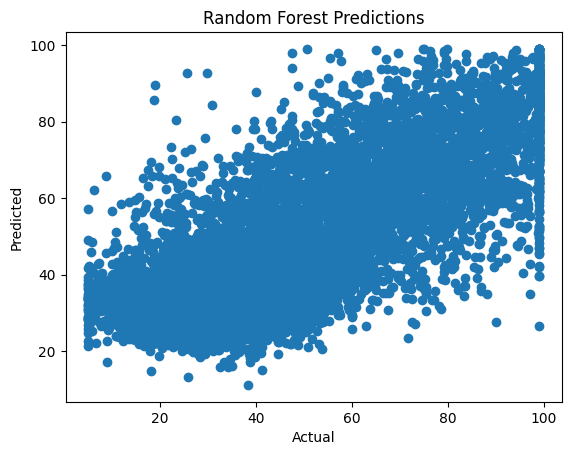

In [12]:
plt.scatter(y_test, rf.predict(X_test))
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Predictions")
plt.show()

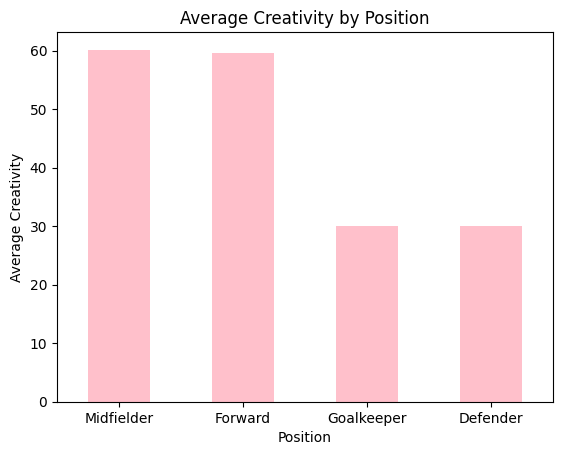

In [31]:
df.groupby('position')['creativity_score'].mean().sort_values(ascending=False).plot(kind='bar', color='pink')
plt.xlabel('Position')
plt.ylabel('Average Creativity')
plt.title('Average Creativity by Position')
plt.xticks(rotation=0)
plt.show()

In [35]:
import pandas as pd
from google.colab import files
df=pd.DataFrame({'Model':['Linear Regression','Random Forest'],'R2 Score':[lr_score,rf_score]})
df.to_csv('model_comparison.csv',index=False)
files.download('model_comparison.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>